# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Krishma-adhikari/flyrank-projects/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 5. Limitations

*What this work cannot claim.*

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


In [65]:
!git clone https://github.com/Krishma-adhikari/flyrank-projects.git

fatal: destination path 'flyrank-projects' already exists and is not an empty directory.


In [66]:
import pandas as pd

In [67]:
df = pd.read_csv('flyrank-projects/data/raw/content_refresh_anonymized.csv')

In [68]:
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [69]:
df.shape

(30000, 44)

In [70]:
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='object')

In [71]:
df.index

RangeIndex(start=0, stop=30000, step=1)

In [72]:
df.isnull().sum()

,0
content_id,0
client_id,0
search_volume,2468
competition,2468
competition_level,2610
cpc,2468
content_type,0
main_intent,2374
word_count,7699
char_count,7699


In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used           8562 non-null   object 
 11  model_used              24267 non-null  object 
 12  impressions_90d         30000 non-null  int64  
 13  clicks_90d              30000 non-null  int64  
 14  pageviews_90d           30000 non-null

In [75]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
search_volume,27532.0,158.882391,1518.270825,0.0,0.0,10.00,20.00,74000.00
competition,27532.0,0.146954,0.285241,0.0,0.0,0.00,0.13,1.00
cpc,27532.0,0.485342,2.101560,0.0,0.0,0.00,0.00,100.36
word_count,22301.0,3107.760325,1452.382598,8.0,2413.0,2877.00,3666.00,9546.00
char_count,22301.0,20665.277835,10115.344042,40.0,15644.0,19116.00,24011.00,111158.00
impressions_90d,30000.0,5200.366300,16838.019547,1.0,81.0,731.00,3615.25,517715.00
clicks_90d,30000.0,16.097333,75.076958,0.0,0.0,1.00,7.00,4178.00
pageviews_90d,30000.0,49.942467,152.101430,0.0,2.0,8.00,33.00,5998.00
sessions_90d,30000.0,37.066633,107.069131,1.0,2.0,7.00,27.00,4345.00
users_90d,30000.0,35.937700,103.748185,1.0,2.0,7.00,27.00,4913.00


In [76]:
df.shape

(30000, 44)

In [77]:
# EDA

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

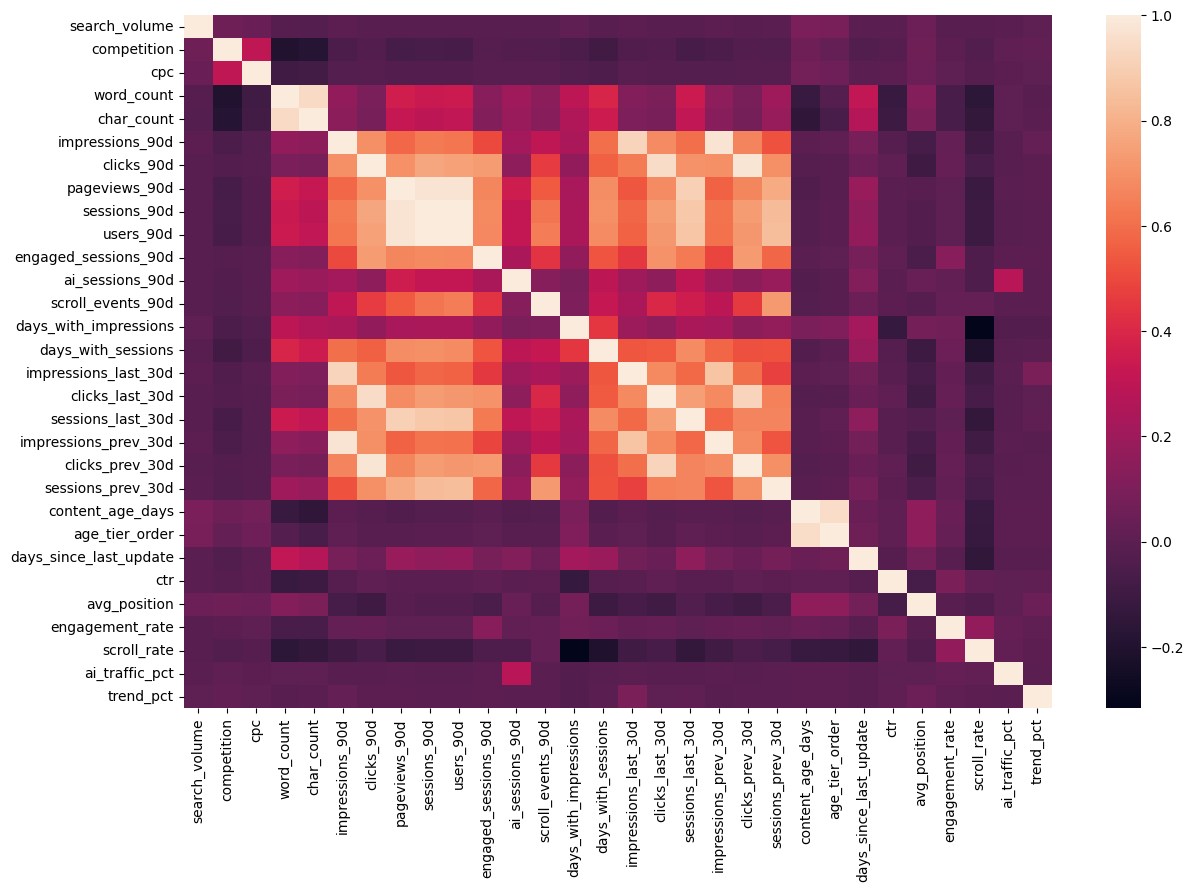

In [79]:
corre = df.corr(numeric_only = True)
plt.figure(figsize=(14,9))
sns.heatmap(corre)
plt.show()

In [80]:
num = df.select_dtypes(include = 'number').columns

In [81]:
cat = df.select_dtypes(include = 'object').columns

In [ ]:
for col in cat:
  sns.countplot(x = col, data = df)
  plt.xticks(rotation = 45)
  plt.show()

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7863992a68e0> (for post_execute):


KeyboardInterrupt: 

In [ ]:
df = df.drop(columns = ['content_id','client_id','age_tier_order'], axis = 1)

In [ ]:
# Handling missing values
df[num] = df[num].fillna(df[num].median())

In [ ]:
df[cat] = df[cat].fillna("Unknown")

In [ ]:
df.isnull().sum()

In [ ]:
df[cat].head()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
preprocessor = ColumnTransformer(transformers = [("num", StandardScaler(),num),("cat",OneHotEncoder(handle_unknown="ignore"),cat)
          ]

)

In [ ]:
X_processed =preprocessor.fit_transform(df)